In [2]:
from experiment_functions import run_experiment, plot_experiment, PERTURBATION_TYPES
from pathlib import Path
import numpy as np

In [ ]:
data_dir   = Path("../data")
file_paths = sorted(data_dir.glob("*.graphml"))[:100]
print(f"Found {len(file_paths)} connectome files")

dt    = 0.01
sigma = 10.0
rho   = 28.0
beta  = 8 / 3

J           = 0.9
input_scale = 0.5
lambda_reg  = 3e-6
seed_base   = 42

t_thermalization = 30.0
t_training       = 100.0 # dropped from 200 to decrease running time
t_prediction     = 50.0

p_values = [0.0, 0.05, 0.10, 0.25, 0.50]
n_runs   = 3       # inner expectation over runs per reservoir
epsilon  = 0.5     # t_div threshold

Found 100 connectome files


In [4]:
results = run_experiment(
    file_paths,
    p_values          = p_values,
    n_runs            = n_runs,
    epsilon           = epsilon,
    J                 = J,
    lambda_reg        = lambda_reg,
    t_thermalization  = t_thermalization,
    t_training        = t_training,
    t_prediction      = t_prediction,
    sigma             = sigma,
    rho               = rho,
    beta              = beta,
    dt                = dt,
    input_scale       = input_scale,
    seed_base         = seed_base,
) 

In [5]:
# save raw results so the experiment does not need to be re-run

out = {}
for mode in PERTURBATION_TYPES:
    for p in p_values:
        out[f"{mode}__p{p:.2f}"] = np.array(results[mode][p])
np.savez("results.npz", **out)
print("Results saved to results.npz")

Results saved to results.npz


/var/folders/kn/yjsfmwwx669fw9ft5g7t128m0000gn/T/ipykernel_72123/596675497.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


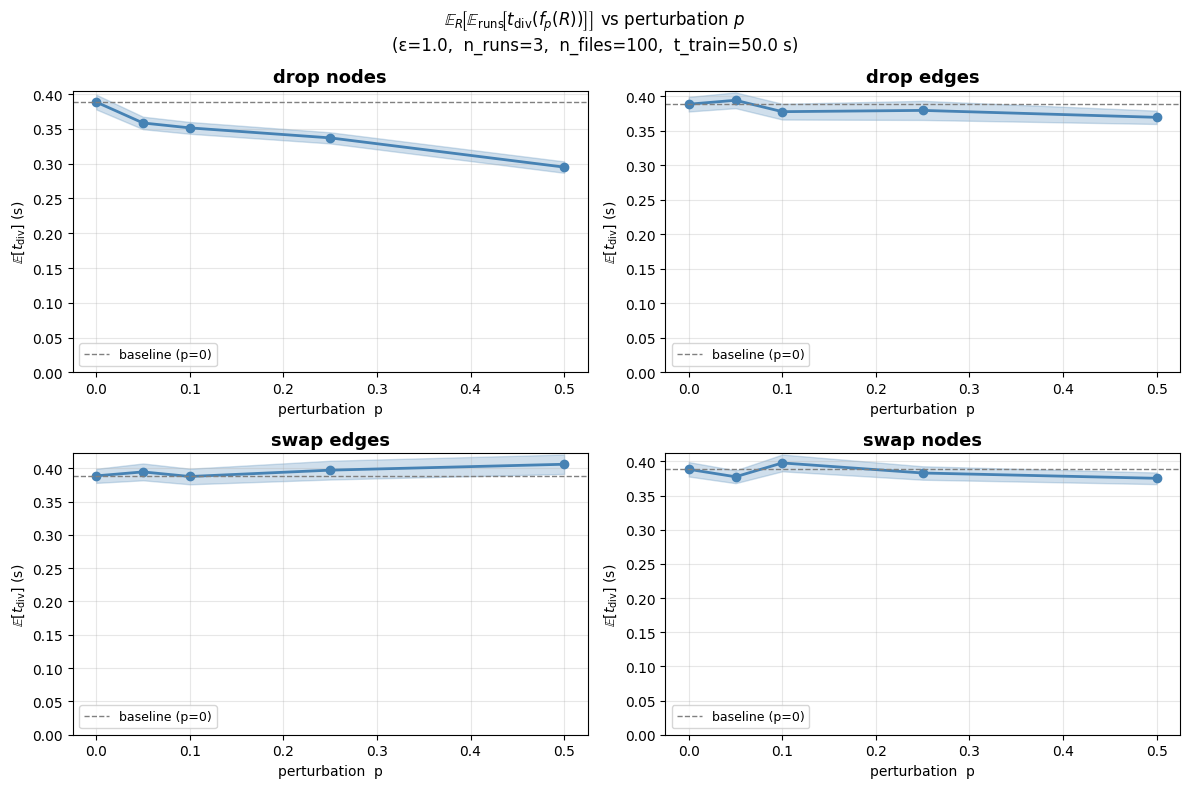

In [6]:
fig = plot_experiment(
    results,
    p_values   = p_values,
    epsilon    = epsilon,
    n_runs     = n_runs,
    n_files    = len(file_paths),
    t_training = t_training,
)
#fig.savefig("experiment_results.png", dpi=150, bbox_inches="tight")
fig.show()